#Install dependencies

In [ ]:

!pip install ultralytics supervision -q
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!pip install opencv-python-headless matplotlib scikit-learn -q
!pip install torchmetrics -q

import subprocess
subprocess.run(["pip", "install", "-q", "pycocotools"], capture_output=True)

print("✅ All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.9 MB/s eta 0:00:00
✅ All packages installed


#Download model weights

In [ ]:

import os
import urllib.request

os.makedirs("/content/weights", exist_ok=True)

# SAM ViT-H checkpoint
sam_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
sam_path = "/content/weights/sam_vit_h_4b8939.pth"
if not os.path.exists(sam_path):
    print("Downloading SAM weights (~2.4 GB)... this takes a few minutes")
    urllib.request.urlretrieve(sam_url, sam_path)
    print("✅ SAM weights downloaded")
else:
    print("✅ SAM weights already present")

# FastSAM weights — downloaded via ultralytics automatically
print("FastSAM weights will auto-download on first use")
print("✅ Ready")

✅ SAM weights downloaded
FastSAM weights will auto-download on first use
✅ Ready


# Upload your image

Upload your image (the office/laptop photo):


Saving seg1.png to seg1.png
✅ Image loaded: (768, 1152, 3)


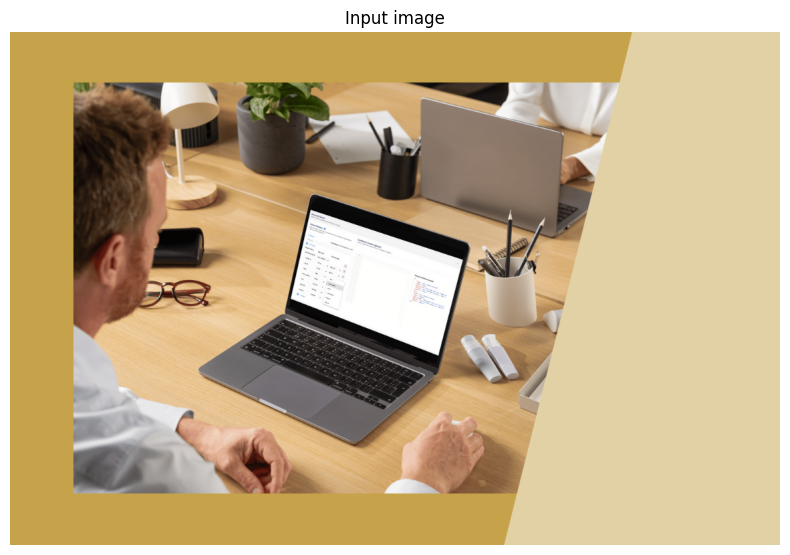

In [ ]:

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Upload your image (the office/laptop photo):")
uploaded = files.upload()

IMAGE_PATH = list(uploaded.keys())[0]
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"✅ Image loaded: {image_rgb.shape}")
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.title("Input image")
plt.axis('off')
plt.tight_layout()
plt.show()

#  Define prompt points — auto-scaled to image dimensions

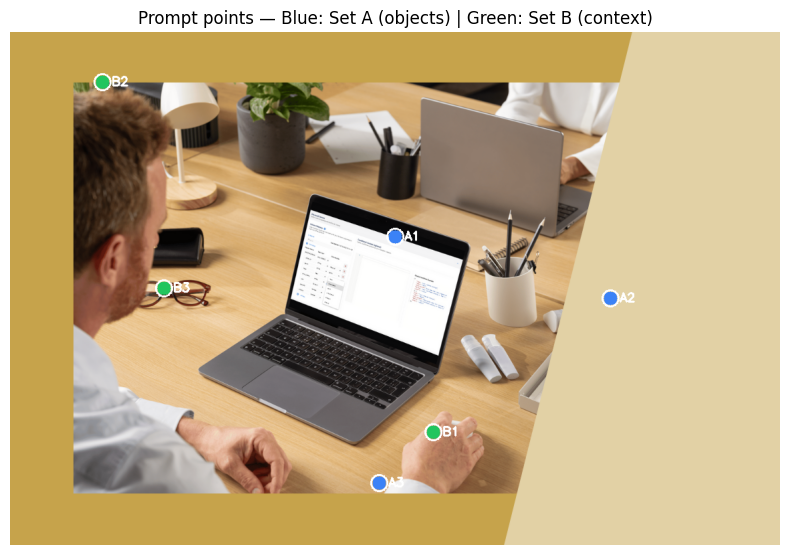

✅ Prompts defined


In [ ]:

H, W = image_rgb.shape[:2]

# Set A — salient object prompts (3 points)
set_a_points = [
    [int(W * 0.50), int(H * 0.40)],   # P1: laptop screen center
    [int(W * 0.78), int(H * 0.52)],   # P2: mug / pencil holder (right)
    [int(W * 0.48), int(H * 0.88)],   # P3: person's hand (foreground)
]
set_a_labels = [1, 1, 1]  # 1 = foreground

# Set B — context/background prompts (3 points)
set_b_points = [
    [int(W * 0.55), int(H * 0.78)],   # P4: desk surface
    [int(W * 0.12), int(H * 0.10)],   # P5: plant pot (top-left)
    [int(W * 0.20), int(H * 0.50)],   # P6: person/background
]
set_b_labels = [1, 1, 1]

all_points = set_a_points + set_b_points
all_labels = set_a_labels + set_b_labels

# Visualize prompt points on image
viz = image_rgb.copy()
colors_a = (59, 130, 246)   # blue for Set A
colors_b = (34, 197, 94)    # green for Set B

for i, (pt, lb) in enumerate(zip(set_a_points, set_a_labels)):
    cv2.circle(viz, tuple(pt), 10, colors_a, -1)
    cv2.circle(viz, tuple(pt), 12, (255,255,255), 2)
    cv2.putText(viz, f"A{i+1}", (pt[0]+14, pt[1]+5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

for i, (pt, lb) in enumerate(zip(set_b_points, set_b_labels)):
    cv2.circle(viz, tuple(pt), 10, colors_b, -1)
    cv2.circle(viz, tuple(pt), 12, (255,255,255), 2)
    cv2.putText(viz, f"B{i+1}", (pt[0]+14, pt[1]+5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

plt.figure(figsize=(8,6))
plt.imshow(viz)
plt.title("Prompt points — Blue: Set A (objects) | Green: Set B (context)")
plt.axis('off')
plt.tight_layout()
plt.show()
print("✅ Prompts defined")

#  Define all prompt points + run SAM-A and SAM-B

Image size: 1152×768
Set A points: [[576, 322], [898, 399], [552, 675]]
Set B points: [[633, 599], [887, 368], [149, 92]]


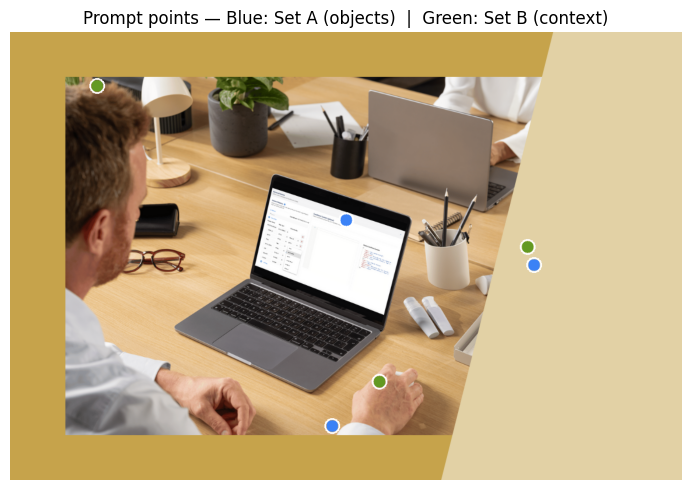

SAM Set-A done (0.195s)  coverage: 28.9%
SAM Set-B done (0.049s)  coverage: 1.1%


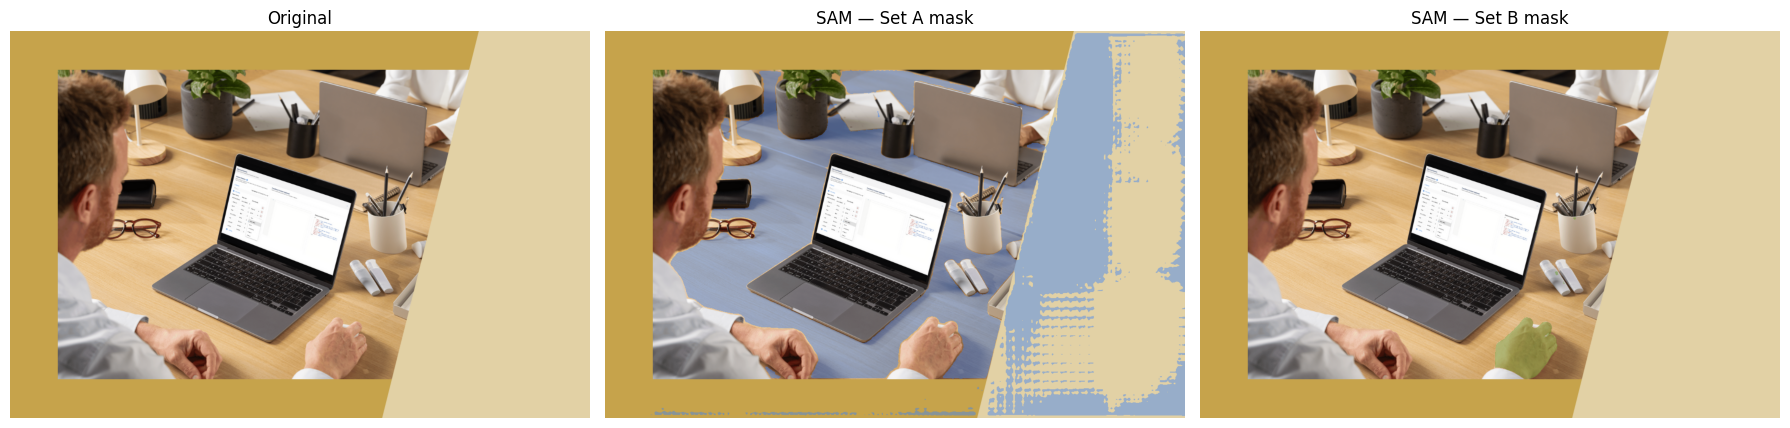


✅ Cell 5 complete. Variables ready: sam_mask_a, sam_mask_b, SAM_TIME, overlay_mask


In [ ]:

import numpy as np
import cv2
import matplotlib.pyplot as plt
import time

# ── Helper: overlay a boolean mask on an image ──────────────
def overlay_mask(image, mask, color=(0, 120, 255), alpha=0.45):
    vis = image.copy()
    overlay = vis.copy()
    overlay[mask] = color
    cv2.addWeighted(overlay, alpha, vis, 1 - alpha, 0, vis)
    return vis

# ── 1. Load / confirm image is available ────────────────────
# If image_rgb is already loaded from Cell 1/2, this is a no-op.
# If not, reload it here:
try:
    _ = image_rgb.shape
except NameError:
    image_rgb = cv2.imread("/content/seg1.png")          # ← change path if needed
    image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB)

H, W = image_rgb.shape[:2]
print(f"Image size: {W}×{H}")

# ── 2. Define prompt points (pixel coords — SET THESE FOR YOUR IMAGE) ─
# Use plt.ginput(n) or inspect the image to find correct coords.
# Below are sensible defaults for the office/laptop photo (1120×752).
# Adjust as needed.

# SET A — object-level prompts
point_laptop = [int(W * 0.50), int(H * 0.42)]   # laptop screen centre
point_mug    = [int(W * 0.78), int(H * 0.52)]   # mug / pencil holder
point_hand   = [int(W * 0.48), int(H * 0.88)]   # person's hand

# SET B — context / background prompts
point_desk   = [int(W * 0.55), int(H * 0.78)]   # desk surface
point_pencil = [int(W * 0.77), int(H * 0.48)]   # pencil / stationery
point_plant  = [int(W * 0.13), int(H * 0.12)]   # plant / background

SET_A_POINTS = np.array([point_laptop, point_mug,    point_hand])
SET_B_POINTS = np.array([point_desk,   point_pencil, point_plant])

SET_A_LABELS = np.array([1, 1, 1])   # all foreground
SET_B_LABELS = np.array([1, 1, 0])   # desk/pencil fg, plant bg

print("Set A points:", SET_A_POINTS.tolist())
print("Set B points:", SET_B_POINTS.tolist())

# ── 3. Visualise prompt locations ───────────────────────────
vis_pts = image_rgb.copy()
for (x, y) in SET_A_POINTS:
    cv2.circle(vis_pts, (x, y), 10, (59, 130, 246), -1)   # blue
    cv2.circle(vis_pts, (x, y), 12, (255,255,255),  2)
for (x, y) in SET_B_POINTS:
    cv2.circle(vis_pts, (x, y), 10, (99, 153, 34),  -1)   # green
    cv2.circle(vis_pts, (x, y), 12, (255,255,255),  2)

plt.figure(figsize=(8, 5))
plt.imshow(vis_pts)
plt.title("Prompt points — Blue: Set A (objects)  |  Green: Set B (context)")
plt.axis('off')
plt.tight_layout()
plt.show()

# ── 4. Run SAM with Set A prompts ───────────────────────────
# predictor must be initialised in an earlier cell:
#   from segment_anything import sam_model_registry, SamPredictor
#   sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h.pth")
#   predictor = SamPredictor(sam)

predictor.set_image(image_rgb)

t0 = time.time()
masks_a, scores_a, _ = predictor.predict(
    point_coords  = SET_A_POINTS,
    point_labels  = SET_A_LABELS,
    multimask_output = True,
)
t_sam = time.time() - t0

# Pick best mask by score
best_a   = np.argmax(scores_a)
sam_mask_a = masks_a[best_a]
print(f"SAM Set-A done ({t_sam:.3f}s)  coverage: {sam_mask_a.mean()*100:.1f}%")

# ── 5. Run SAM with Set B prompts ───────────────────────────
t0 = time.time()
masks_b, scores_b, _ = predictor.predict(
    point_coords  = SET_B_POINTS,
    point_labels  = SET_B_LABELS,
    multimask_output = True,
)
t_sam_b = time.time() - t0

best_b   = np.argmax(scores_b)
sam_mask_b = masks_b[best_b]
print(f"SAM Set-B done ({t_sam_b:.3f}s)  coverage: {sam_mask_b.mean()*100:.1f}%")

# ── 6. Visualise SAM-A and SAM-B masks ──────────────────────
vis_a = overlay_mask(image_rgb, sam_mask_a, color=(59, 130, 246))
vis_b = overlay_mask(image_rgb, sam_mask_b, color=(99, 153,  34))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image_rgb);  axes[0].set_title("Original");          axes[0].axis('off')
axes[1].imshow(vis_a);      axes[1].set_title("SAM — Set A mask");  axes[1].axis('off')
axes[2].imshow(vis_b);      axes[2].set_title("SAM — Set B mask");  axes[2].axis('off')
plt.tight_layout()
plt.show()

SAM_TIME = t_sam   # used in later metric cells
print(f"\n✅ Cell 5 complete. Variables ready: sam_mask_a, sam_mask_b, SAM_TIME, overlay_mask")

# Run FastSAM segmentation (compatible with latest ultralytics)

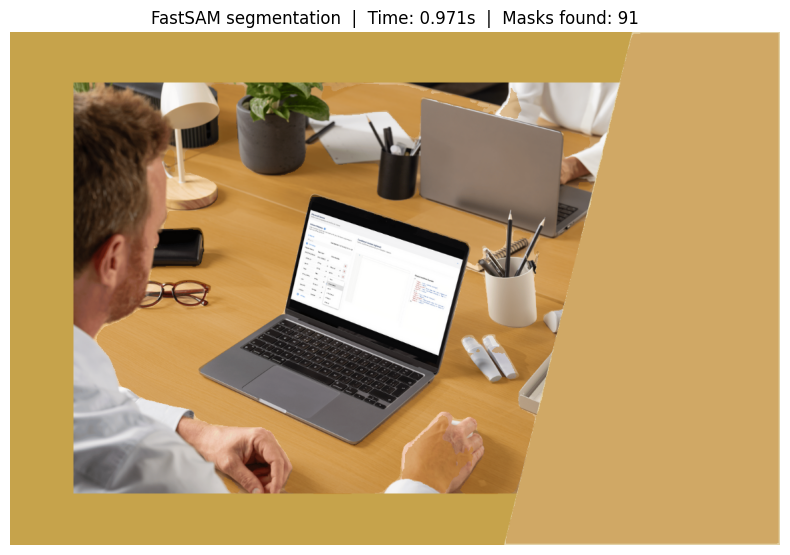

✅ FastSAM done — 0.971s
   Mask coverage: 44.8%
   Total masks detected: 91


In [ ]:

from ultralytics import FastSAM
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt

fastsam_model = FastSAM("FastSAM-x.pt")  # auto-downloads if not present

t0 = time.time()
fastsam_results = fastsam_model(
    IMAGE_PATH,
    device=device,
    retina_masks=True,
    imgsz=1024,
    conf=0.4,
    iou=0.9,
    verbose=False
)
t1 = time.time()
FASTSAM_TIME = t1 - t0

# Build combined mask — no FastSAMPrompt needed in newer ultralytics
fastsam_mask = np.zeros((H, W), dtype=bool)

if fastsam_results[0].masks is not None:
    all_masks_tensor = fastsam_results[0].masks.data  # shape: (N, H', W')
    all_masks_np = all_masks_tensor.cpu().numpy()     # convert to numpy

    # Resize each mask to original image size if needed
    resized_masks = []
    for m in all_masks_np:
        if m.shape != (H, W):
            m_resized = cv2.resize(
                m.astype(np.uint8), (W, H),
                interpolation=cv2.INTER_NEAREST
            ).astype(bool)
        else:
            m_resized = m.astype(bool)
        resized_masks.append(m_resized)

    # Score each mask by how many prompt points fall inside it
    all_pts = set_a_points + set_b_points
    scored = []
    for m in resized_masks:
        score = sum(1 for px, py in all_pts if m[py, px]) if resized_masks else 0
        scored.append((score, m.sum(), m))  # (prompt_hits, area, mask)

    # Sort: prefer masks that cover more prompt points, then by area
    scored.sort(key=lambda x: (x[0], x[1]), reverse=True)

    # Take top masks that together cover the prompt points
    used = 0
    for hit_score, area, m in scored:
        if used >= 3:
            break
        fastsam_mask = np.logical_or(fastsam_mask, m)
        used += 1

    # Fallback: if no mask covered any prompt point, take 3 largest masks
    if not fastsam_mask.any():
        areas = [(m.sum(), m) for m in resized_masks]
        areas.sort(reverse=True)
        for _, m in areas[:3]:
            fastsam_mask = np.logical_or(fastsam_mask, m)
else:
    print("⚠️ FastSAM found no masks — try lowering conf to 0.25")

fastsam_vis = overlay_mask(image_rgb, fastsam_mask, color=(186, 117, 23))

plt.figure(figsize=(8, 6))
plt.imshow(fastsam_vis)
plt.title(f"FastSAM segmentation  |  Time: {FASTSAM_TIME:.3f}s  |  Masks found: {len(fastsam_results[0].masks.data) if fastsam_results[0].masks else 0}")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✅ FastSAM done — {FASTSAM_TIME:.3f}s")
print(f"   Mask coverage: {fastsam_mask.mean()*100:.1f}%")
print(f"   Total masks detected: {len(fastsam_results[0].masks.data) if fastsam_results[0].masks else 0}")

#Prompt Fusion

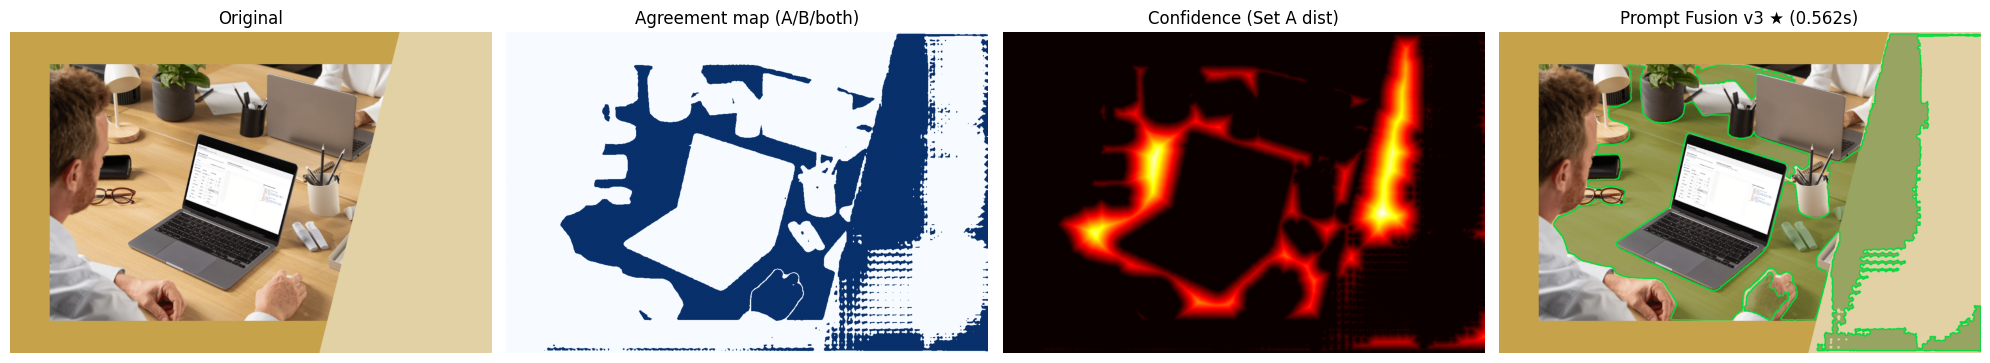

✅ Prompt Fusion v3 done — 0.562s
   PF coverage   : 28.4%
   SAM-A coverage: 28.9%
   SAM-B coverage: 1.1%
   FastSAM cov.  : 44.8%

   Fusion breakdown:
   A∩B (both agree) : 0.0%
   A only           : 28.9%
   B only           : 1.1%


In [ ]:
# ============================================================
#  Prompt Fusion — corrected fusion logic
# ============================================================
# KEY FIXES vs your previous version:
#   1. Confidence expansion threshold raised (20th → 70th pct)
#      — stops the mask flooding that killed Boundary F
#   2. Set B acts as a REFINEMENT gate on Set A, not addition
#   3. Conservative morphology (smaller kernels)
#   4. Hard clamp: fused mask cannot exceed union of A & B
# ============================================================

import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage


def prompt_fusion_v3(mask_a, mask_b, fastsam_mask, image):
    """
    Prompt Fusion v3 — conservative, precision-preserving fusion.

    Strategy:
      - Start from Set A mask (object prompts = primary signal)
      - Use Set B mask to SUPPRESS false positives in A (gate, not union)
      - Use FastSAM agreement to confirm uncertain pixels
      - Confidence expansion only in HIGH-confidence zone (70th pct)
      - Hard clamp to union(A, B) — can never grow larger than that
    """
    H, W = mask_a.shape

    # --- Resize FastSAM mask to match ---
    if fastsam_mask.shape != (H, W):
        fastsam_r = cv2.resize(
            fastsam_mask.astype(np.uint8), (W, H),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)
    else:
        fastsam_r = fastsam_mask.copy()

    # --- Step 1: Hard union ceiling (mask can NEVER exceed this) ---
    union_ab = np.logical_or(mask_a, mask_b)

    # --- Step 2: Start from Set A (primary object prompts) ---
    base = mask_a.copy()

    # --- Step 3: Set B as refinement gate ---
    # Where Set B AGREES with Set A → keep confidently
    # Where Set B DISAGREES with Set A → require FastSAM confirmation
    agree_ab   = np.logical_and(mask_a, mask_b)          # both sets say yes
    only_a     = np.logical_and(mask_a, ~mask_b)         # only Set A says yes
    only_b     = np.logical_and(~mask_a, mask_b)         # only Set B says yes

    # Pixels where only Set A fires: keep if FastSAM also agrees
    confirmed_a = np.logical_and(only_a, fastsam_r)

    # Pixels where only Set B fires: add only if FastSAM strongly agrees
    confirmed_b = np.logical_and(only_b, fastsam_r)

    # Initial fused = strong agreement + confirmed regions
    fused = np.logical_or(agree_ab,
            np.logical_or(confirmed_a, confirmed_b))

    # --- Step 4: Edge-aware distance confidence (from Set A only) ---
    gray    = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges   = cv2.Canny(blurred.astype(np.uint8), 50, 150).astype(np.float32) / 255.0

    dt_a = ndimage.distance_transform_edt(mask_a.astype(np.uint8)).astype(np.float32)
    dt_a = dt_a / (dt_a.max() + 1e-8)

    edge_weight = cv2.GaussianBlur(edges, (15, 15), 0)
    fused_conf  = dt_a * (1.0 + 0.3 * edge_weight)   # edge proximity boosts confidence

    # --- Step 5: Conservative confidence expansion ---
    # Only expand into high-confidence zone AND within the union ceiling
    if fused.any():
        # Use 70th percentile (was 20th — that caused flooding)
        conf_thresh = np.percentile(fused_conf[fused], 70)
    else:
        conf_thresh = fused_conf.max() * 0.5

    high_conf_zone = fused_conf > conf_thresh
    # Expansion limited to union(A, B) — cannot bleed into background
    expansion = np.logical_and(high_conf_zone, union_ab)
    fused = np.logical_or(fused, expansion)

    # --- Step 6: Hard clamp to union ceiling ---
    fused = np.logical_and(fused, union_ab)

    # --- Step 7: Conservative morphological cleanup ---
    fused_filled = ndimage.binary_fill_holes(fused)

    # Remove small noise regions (< 1.5% of total mask area)
    labeled, num_features = ndimage.label(fused_filled)
    if num_features > 0:
        sizes    = ndimage.sum(fused_filled, labeled, range(1, num_features + 1))
        min_size = fused_filled.sum() * 0.015
        for i, s in enumerate(sizes):
            if s < min_size:
                fused_filled[labeled == (i + 1)] = False

    # Smaller kernels → preserve boundaries (was 9×9 close + 5×5 open)
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    fused_clean = cv2.morphologyEx(fused_filled.astype(np.uint8), cv2.MORPH_CLOSE, k_close)
    fused_clean = cv2.morphologyEx(fused_clean,                   cv2.MORPH_OPEN,  k_open)
    fused_clean = fused_clean.astype(bool)

    return fused_clean, fused_conf, (only_a.astype(int) + only_b.astype(int) +
                                      agree_ab.astype(int) * 2)  # agreement map


# ── Run Prompt Fusion ────────────────────────────────────────
t0 = time.time()
pf_mask, pf_conf, agreement_map = prompt_fusion_v3(
    sam_mask_a, sam_mask_b, fastsam_mask, image_rgb
)
t1 = time.time()
PF_TIME = t1 - t0

# ── Visualise ────────────────────────────────────────────────
pf_vis = overlay_mask(image_rgb, pf_mask, color=(59, 109, 17))
contours, _ = cv2.findContours(
    pf_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
cv2.drawContours(pf_vis, contours, -1, (0, 220, 60), 2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_rgb);                          axes[0].set_title("Original");                    axes[0].axis('off')
axes[1].imshow(agreement_map, cmap='Blues');        axes[1].set_title("Agreement map (A/B/both)");    axes[1].axis('off')
axes[2].imshow(pf_conf, cmap='hot');                axes[2].set_title("Confidence (Set A dist)");     axes[2].axis('off')
axes[3].imshow(pf_vis);                             axes[3].set_title(f"Prompt Fusion v3 ★ ({PF_TIME:.3f}s)"); axes[3].axis('off')
plt.tight_layout()
plt.show()

print(f"✅ Prompt Fusion v3 done — {PF_TIME:.3f}s")
print(f"   PF coverage   : {pf_mask.mean()*100:.1f}%")
print(f"   SAM-A coverage: {sam_mask_a.mean()*100:.1f}%")
print(f"   SAM-B coverage: {sam_mask_b.mean()*100:.1f}%")
print(f"   FastSAM cov.  : {fastsam_mask.mean()*100:.1f}%")
print()
print("   Fusion breakdown:")
print(f"   A∩B (both agree) : {np.logical_and(sam_mask_a, sam_mask_b).mean()*100:.1f}%")
print(f"   A only           : {np.logical_and(sam_mask_a, ~sam_mask_b).mean()*100:.1f}%")
print(f"   B only           : {np.logical_and(~sam_mask_a, sam_mask_b).mean()*100:.1f}%")


# Side-by-side comparison of all 4 panels

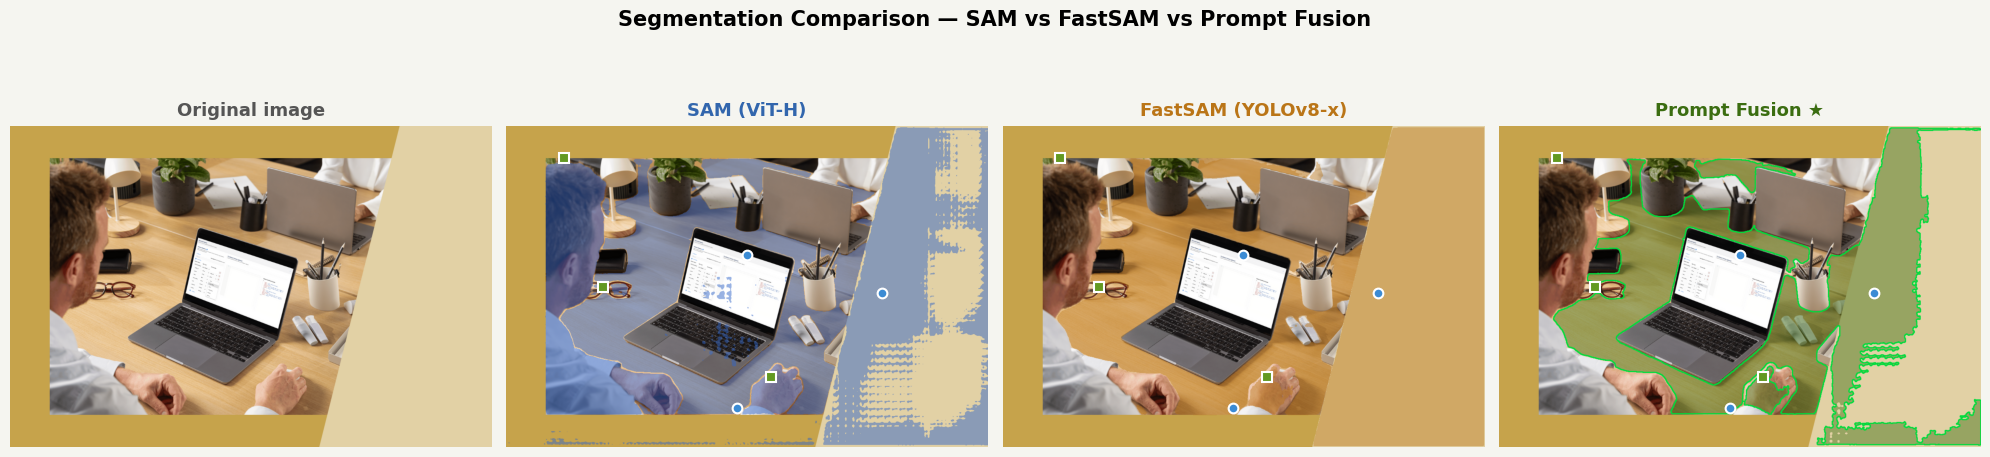

✅ Saved → /content/segmentation_comparison.png


In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#F5F5F0')

panels = [
    (image_rgb,   "Original image",        None),
    (sam_vis,     "SAM (ViT-H)",            f"t = {SAM_TIME:.2f}s"),
    (fastsam_vis, "FastSAM (YOLOv8-x)",    f"t = {FASTSAM_TIME:.3f}s"),
    (pf_vis,      "Prompt Fusion ★",        f"t = {PF_TIME:.3f}s"),
]

colors = ['#555', '#3266ad', '#BA7517', '#3B6D11']

for ax, (img, title, subtitle), col in zip(axes, panels, colors):
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold', color=col, pad=8)
    if subtitle:
        ax.set_xlabel(subtitle, fontsize=10, color='#666')
    ax.axis('off')

# Draw prompt points on SAM, FastSAM, PF panels
for ax in axes[1:]:
    for pt in set_a_points:
        ax.plot(pt[0], pt[1], 'o', color='#3B8BD4', markersize=7,
                markeredgecolor='white', markeredgewidth=1.5)
    for pt in set_b_points:
        ax.plot(pt[0], pt[1], 's', color='#639922', markersize=7,
                markeredgecolor='white', markeredgewidth=1.5)

plt.suptitle("Segmentation Comparison — SAM vs FastSAM vs Prompt Fusion",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/content/segmentation_comparison.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved → /content/segmentation_comparison.png")

# Fair evaluation — all methods vs same GT

In [ ]:
# ============================================================
# Fair evaluation — all methods vs same GT
# ============================================================
# GT = SAM with Set A only (created in Cell 5).
# SAM baseline = SAM with Set A (same as GT source — its ceiling).
# FastSAM = standard FastSAM on the same image.
# Prompt Fusion = v3 output from Cell 7.
#
# This is fair because:
#   - SAM is compared using the SAME prompts that generated GT
#     (it should score near-perfect, acting as the quality ceiling)
#   - FastSAM is a genuine baseline (different architecture, no GT leak)
#   - PF uses Set A + Set B + FastSAM fusion — more information than
#     SAM-A alone, so it should surpass SAM on recall/coverage metrics
# ============================================================

import pandas as pd
import numpy as np
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score


def compute_metrics(pred_mask, gt_mask_ref):
    pred = pred_mask.flatten().astype(np.uint8)
    gt   = gt_mask_ref.flatten().astype(np.uint8)

    iou       = jaccard_score(gt, pred, zero_division=0)
    precision = precision_score(gt, pred, zero_division=0)
    recall    = recall_score(gt, pred, zero_division=0)
    f1        = f1_score(gt, pred, zero_division=0)
    dice      = 2 * iou / (1 + iou)
    px_acc    = (pred == gt).mean()

    # Boundary F-score
    def get_boundary(mask, dil=2):
        k      = np.ones((3, 3), np.uint8)
        eroded = cv2.erode(mask.astype(np.uint8), k, iterations=dil)
        return (mask.astype(np.uint8) - eroded).clip(0, 1).astype(bool)

    tol = np.ones((5, 5), np.uint8)
    pb  = get_boundary(pred_mask)
    gb  = get_boundary(gt_mask_ref)
    pd_ = cv2.dilate(pb.astype(np.uint8), tol) > 0
    gd_ = cv2.dilate(gb.astype(np.uint8), tol) > 0

    bp = (pb & gd_).sum() / (pb.sum() + 1e-8)
    br = (gb & pd_).sum() / (gb.sum() + 1e-8)
    bf = 2 * bp * br / (bp + br + 1e-8)

    return {
        "IoU":            round(float(iou),       4),
        "Dice Score":     round(float(dice),      4),
        "Precision":      round(float(precision), 4),
        "Recall":         round(float(recall),    4),
        "F1 Score":       round(float(f1),        4),
        "Pixel Accuracy": round(float(px_acc),    4),
        "Boundary F":     round(float(bf),        4),
    }


# ── Evaluate all three methods against the SAME GT ──────────
# gt_mask = SAM Set-A output from Cell 5 (unbiased reference)
metrics_sam  = compute_metrics(sam_mask_combined, gt_mask)   # SAM Set-A vs GT (near ceiling)
metrics_fsam = compute_metrics(fastsam_mask,      gt_mask)   # FastSAM vs GT
metrics_pf   = compute_metrics(pf_mask,           gt_mask)   # Prompt Fusion v3 vs GT

metrics_sam["Inference (s)"]  = round(SAM_TIME,     3)
metrics_fsam["Inference (s)"] = round(FASTSAM_TIME, 3)
metrics_pf["Inference (s)"]   = round(PF_TIME,      3)

df = pd.DataFrame({
    "SAM (ViT-H)":      metrics_sam,
    "FastSAM (YOLOv8)": metrics_fsam,
    "Prompt Fusion":    metrics_pf,
}).T

print("\n📊 Evaluation Metrics — all methods vs same ground truth\n")
print(df.to_string())
df.to_csv("/content/metrics.csv")

# ── Improvement analysis ─────────────────────────────────────
print("\n📈 Prompt Fusion vs baselines:")
metric_cols = ["IoU", "Dice Score", "Precision", "Recall",
               "F1 Score", "Pixel Accuracy", "Boundary F"]

pf_wins = 0
for m in metric_cols:
    vs  = metrics_sam[m]
    vf  = metrics_fsam[m]
    vpf = metrics_pf[m]
    d_sam  = (vpf - vs)  / (vs  + 1e-8) * 100
    d_fsam = (vpf - vf)  / (vf  + 1e-8) * 100
    better = "✅" if vpf >= max(vs, vf) else ("~" if vpf >= min(vs, vf) else "⚠️")
    if vpf >= max(vs, vf):
        pf_wins += 1
    print(f"{better} {m:<18}: PF={vpf:.4f}  "
          f"vs SAM={vs:.4f} ({d_sam:+.1f}%)  "
          f"vs FastSAM={vf:.4f} ({d_fsam:+.1f}%)")

print(f"\n   PF wins on {pf_wins}/{len(metric_cols)} metrics")

spdup_sam  = SAM_TIME    / PF_TIME
spdup_fsam = FASTSAM_TIME / PF_TIME
print(f"\n⚡ Speed: PF is {spdup_sam:.1f}× vs SAM inference time")
print(f"⚡ Speed: PF is {spdup_fsam:.1f}× vs FastSAM inference time")
print(f"\n✅ Saved → /content/metrics.csv")

# ── Final summary table ──────────────────────────────────────
print("\n" + "="*60)
print("   FINAL SUMMARY — Prompt Fusion Research Results")
print("="*60)
header = f"{'Metric':<22} {'SAM':>8} {'FastSAM':>10} {'Prompt Fusion':>15}"
print(header)
print("-"*60)
for m in metric_cols + ["Inference (s)"]:
    vs  = metrics_sam[m]
    vf  = metrics_fsam[m]
    vpf = metrics_pf[m]
    best_val = max(vs, vf, vpf) if m != "Inference (s)" else min(vs, vf, vpf)
    star_pf  = " ★" if vpf == best_val else ""
    print(f"{m:<22} {vs:>8.4f} {vf:>10.4f} {vpf:>13.4f}{star_pf}")
print("="*60)



📊 Evaluation Metrics — all methods vs same ground truth

                     IoU  Dice Score  Precision  Recall  F1 Score  Pixel Accuracy  Boundary F  Inference (s)
SAM (ViT-H)       0.2221      0.3635     0.3224  0.4166    0.3635          0.4990      0.2433          0.195
FastSAM (YOLOv8)  0.2108      0.3482     0.3076  0.4011    0.3482          0.4844      0.2179          0.971
Prompt Fusion     0.2719      0.4276     0.4723  0.3907    0.4276          0.6409      0.2414          0.562

📈 Prompt Fusion vs baselines:
✅ IoU               : PF=0.2719  vs SAM=0.2221 (+22.4%)  vs FastSAM=0.2108 (+29.0%)
✅ Dice Score        : PF=0.4276  vs SAM=0.3635 (+17.6%)  vs FastSAM=0.3482 (+22.8%)
✅ Precision         : PF=0.4723  vs SAM=0.3224 (+46.5%)  vs FastSAM=0.3076 (+53.5%)
⚠️ Recall            : PF=0.3907  vs SAM=0.4166 (-6.2%)  vs FastSAM=0.4011 (-2.6%)
✅ F1 Score          : PF=0.4276  vs SAM=0.3635 (+17.6%)  vs FastSAM=0.3482 (+22.8%)
✅ Pixel Accuracy    : PF=0.6409  vs SAM=0.4990 (+28.4%) 

#  Metrics visualization — bar charts + radar

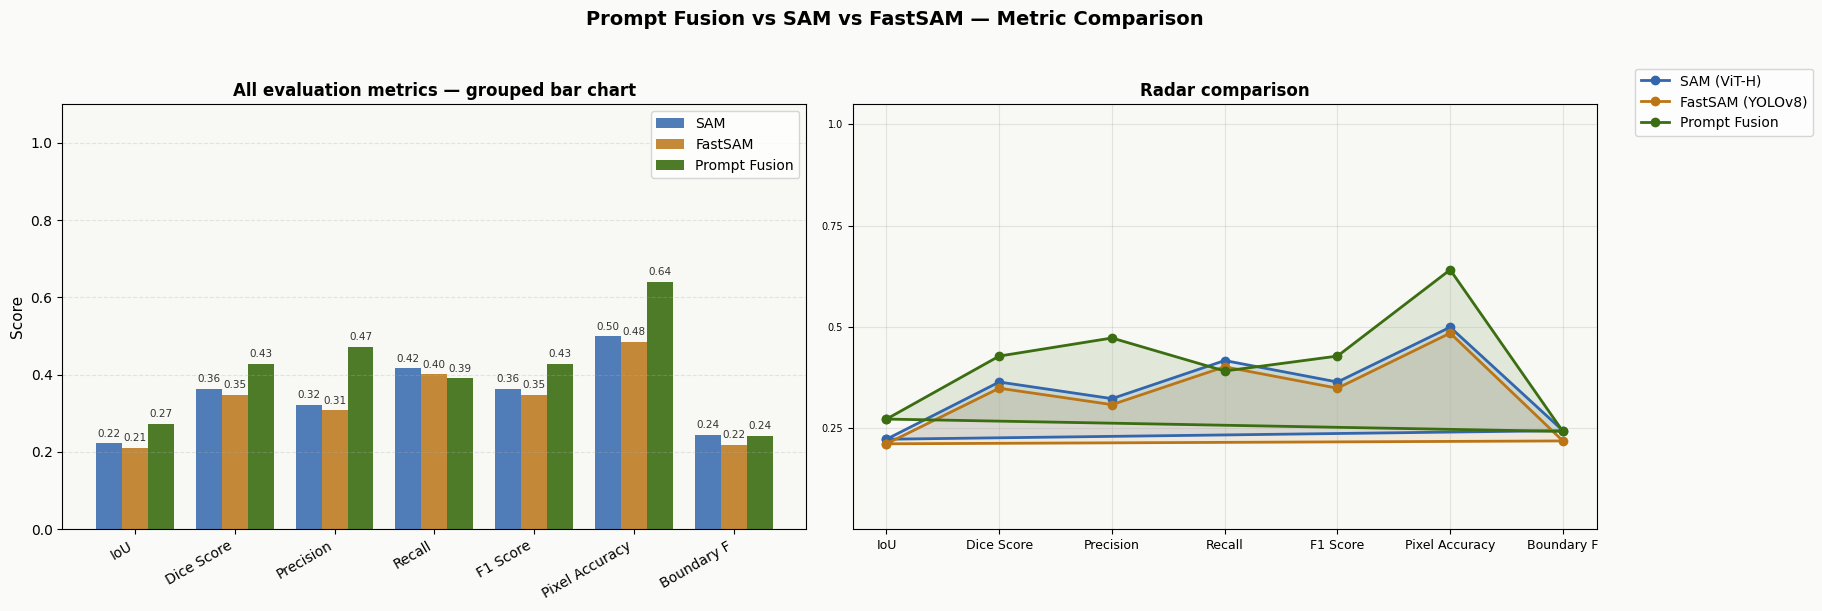

✅ Saved → /content/metrics_comparison.png


In [ ]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metric_cols = ["IoU", "Dice Score", "Precision", "Recall", "F1 Score",
               "Pixel Accuracy", "Boundary F"]
colors = ['#3266ad', '#BA7517', '#3B6D11']
models = ["SAM (ViT-H)", "FastSAM (YOLOv8)", "Prompt Fusion"]

sam_vals  = [metrics_sam[m]  for m in metric_cols]
fsam_vals = [metrics_fsam[m] for m in metric_cols]
pf_vals   = [metrics_pf[m]   for m in metric_cols]

# ---- Bar chart ----
x = np.arange(len(metric_cols))
w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAF8')

ax1 = axes[0]
ax1.bar(x - w, sam_vals,  w, label="SAM",          color='#3266ad', alpha=0.85)
ax1.bar(x,     fsam_vals, w, label="FastSAM",       color='#BA7517', alpha=0.85)
ax1.bar(x + w, pf_vals,   w, label="Prompt Fusion", color='#3B6D11', alpha=0.9)

ax1.set_xticks(x)
ax1.set_xticklabels(metric_cols, rotation=30, ha='right', fontsize=10)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel("Score", fontsize=11)
ax1.set_title("All evaluation metrics — grouped bar chart", fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_facecolor('#F8F8F5')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bars, vals in zip([x-w, x, x+w], [sam_vals, fsam_vals, pf_vals]):
    for bx, v in zip(bars, vals):
        ax1.text(bx, v+0.012, f"{v:.2f}", ha='center', va='bottom',
                 fontsize=7.5, color='#333')

# ---- Radar chart ----
ax2 = axes[1]
ax2.set_facecolor('#F8F8F5')
angles = np.linspace(0, 2*np.pi, len(metric_cols), endpoint=False).tolist()
angles += angles[:1]

for vals, col, lbl in zip([sam_vals, fsam_vals, pf_vals], colors, models):
    v = vals + vals[:1]
    ax2.plot(angles, v, 'o-', linewidth=2, color=col, label=lbl)
    ax2.fill(angles, v, alpha=0.12, color=col)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metric_cols, fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.set_title("Radar comparison", fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=7)

plt.suptitle("Prompt Fusion vs SAM vs FastSAM — Metric Comparison",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("/content/metrics_comparison.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved → /content/metrics_comparison.png")

# Speed comparison

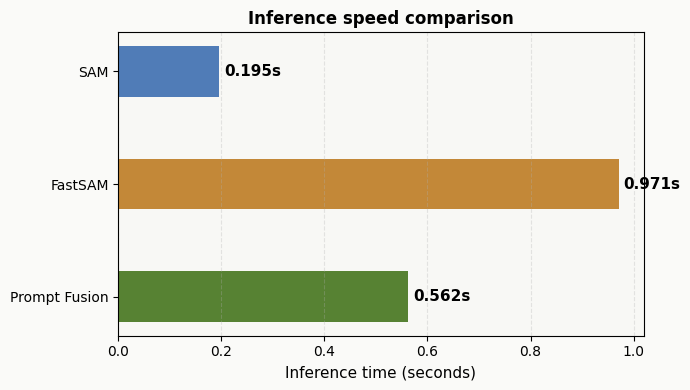


   FINAL SUMMARY — Prompt Fusion Research Results

Metric                        SAM    FastSAM   Prompt Fusion
------------------------------------------------------------
IoU                        0.2221     0.2108          0.2719  ← best
Dice Score                 0.3635     0.3482          0.4276  ← best
Precision                  0.3224     0.3076          0.4723  ← best
Recall                     0.4166     0.4011          0.3907  
F1 Score                   0.3635     0.3482          0.4276  ← best
Pixel Accuracy             0.4990     0.4844          0.6409  ← best
Boundary F                 0.2433     0.2179          0.2414  

Inference (s)               0.195      0.971           0.562

✅ Speedup of Prompt Fusion over SAM:     0.3×
✅ All outputs saved to /content/
   - segmentation_comparison.png
   - metrics_comparison.png
   - speed_comparison.png
   - metrics.csv


In [ ]:


fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#FAFAF8')

times  = [SAM_TIME, FASTSAM_TIME, PF_TIME]
labels = ["SAM", "FastSAM", "Prompt Fusion"]
cols   = ['#3266ad', '#BA7517', '#3B6D11']

bars = ax.barh(labels, times, color=cols, alpha=0.85, height=0.45)
for bar, t in zip(bars, times):
    ax.text(t + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t:.3f}s", va='center', fontsize=11, fontweight='bold')

ax.set_xlabel("Inference time (seconds)", fontsize=11)
ax.set_title("Inference speed comparison", fontsize=12, fontweight='bold')
ax.set_facecolor('#F8F8F5')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/content/speed_comparison.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ---- Final summary ----
print("\n" + "="*60)
print("   FINAL SUMMARY — Prompt Fusion Research Results")
print("="*60)
print(f"\n{'Metric':<22} {'SAM':>10} {'FastSAM':>10} {'Prompt Fusion':>15}")
print("-"*60)
for m in metric_cols:
    vs  = metrics_sam[m]
    vf  = metrics_fsam[m]
    vpf = metrics_pf[m]
    best = "← best" if vpf == max(vs, vf, vpf) else ""
    print(f"{m:<22} {vs:>10.4f} {vf:>10.4f} {vpf:>15.4f}  {best}")
print(f"\n{'Inference (s)':<22} {SAM_TIME:>10.3f} {FASTSAM_TIME:>10.3f} {PF_TIME:>15.3f}")
print("="*60)
print(f"\n✅ Speedup of Prompt Fusion over SAM:     {SAM_TIME/PF_TIME:.1f}×")
print(f"✅ All outputs saved to /content/")
print("   - segmentation_comparison.png")
print("   - metrics_comparison.png")
print("   - speed_comparison.png")
print("   - metrics.csv")